## Question: Do bouroughs with more computer centers, libraries, or literacy programs show higher literacy outcomes? 

In [1]:
import  pandas as pd
import seaborn as sns
import plotly.express as px

raw_Computer_Centers = pd.read_csv("Computer_Centers.csv")
raw_Computer_Centers

,Calendar Year,Object Identification Number,Oversight Agency,Operator Name,Status,Location Name,State,Borough,Postcode,Address Street,...,Access Requirements,Access Notes,URL,Community District,Council District,BIN,BBL,Census Tract (2020),Neighborhood Tabulation Area (NTA) (2020),Location
0,2025,DFTAPCCARC297,NYC Aging,Arc Xvi Fort Washington Inc,NaN,AP Randolph Senior Center,NY,Manhattan,10039.0,"108 West 146th Street, 10039, Manhattan, New Y...",...,N,NaN,http://www.arcseniors.org,110.0,9.0,1060189.0,1.020140e+09,232.0,MN1002,POINT (-73.9364039 40.8212896)
1,2025,DFTAPCCJEW544,NYC Aging,Jewish Association For Services For The Aged,NaN,Club 76 Older Adult Center,NY,Manhattan,10023.0,"120 West 76th Street, 10023, Manhattan, New Yo...",...,Y,Age 60+,http://jasa.org,107.0,6.0,1030146.0,1.011470e+09,161.0,MN0702,POINT (-73.97818199999999 40.7803034)
2,2025,DFTAPCCBAY803,NYC Aging,Bay Ridge Center Inc. D/B/A Bay Ridge Center,NaN,Bay Ridge Center,NY,Brooklyn,11220.0,"15 Bay Ridge Avenue, 11220, Brooklyn, New York...",...,Y,Age 60+,http://Www.bayridgecenter.org,310.0,47.0,3144947.0,3.058590e+09,34.0,BK1001,POINT (-74.0350614 40.6387629)
3,2025,DYCDW119205,Department of Youth and Community Development ...,Department of Youth and Community Development ...,NaN,Dream Center Harlem,NY,Manhattan,10026.0,"205 West 119th Street, 10026, Manhattan, New Y...",...,N,NaN,http://www.dreamcenterharlem.org,110.0,9.0,1088701.0,1.019250e+09,220.0,MN1001,POINT (-73.951702 40.805646)
4,2025,DFTAPCCBOW279,NYC Aging,Bowery Residence Committee,NaN,BRC Older Adults Center,NY,Manhattan,10002.0,"30 Delancey Street, 10002, Manhattan, New York...",...,Y,Age 60+,http://www.brc.org,103.0,1.0,1079081.0,1.004200e+09,18.0,MN0302,POINT (-73.9922313 40.7203881)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
960,2026,DYCDPCCST102,Department of Youth and Community Development ...,Stanley M. Isaacs Neighborhood Center,Currently open,Stanley M. Isaacs Neighborhood Community Center,NY,Manhattan,10128.0,"415 E 93rd St, Manhattan, 10128, NY",...,NaN,NaN,http://isaacscenter.org,108.0,8.0,1082367.0,1.015730e+09,152.0,MN0803,POINT (-73.9451475 40.7812375)
961,2026,PARKS012,NYC Parks & Recreation,NYC Parks & Recreation,Temporarily closed,Hamilton Fish Recreation Center,NY,Manhattan,10002.0,"128 Pitt Street, Manhattan, 10002, NY",...,NaN,NaN,https://www.nycgovparks.org/facilities/recreat...,103.0,2.0,1081934.0,1.003400e+09,2201.0,MN0302,POINT (-73.9814613 40.7199938)
962,2026,QPL029,Queens Public Library (QPL),Queens Public Library (QPL),Currently open,Hunters Point Library,NY,Queens,11109.0,"47-40 Center Boulevard, Queens, 11109, NY",...,N,NaN,https://www.queenslibrary.org/about-us/locatio...,402.0,26.0,4594151.0,4.000190e+09,102.0,QN0201,POINT (-73.9580495 40.7453068)
963,2026,QPL045,Queens Public Library (QPL),Queens Public Library (QPL),Currently open,Pomonok Library,NY,Queens,11365.0,"158-21 Jewel Avenue, Queens, 11365, NY",...,N,NaN,https://www.queenslibrary.org/about-us/locatio...,408.0,24.0,4438294.0,4.067900e+09,122703.0,QN0802,POINT (-73.8101067 40.7326235)


In [2]:
raw_Computer_Centers.columns = raw_Computer_Centers.columns.str.lower().str.replace(" ", "_")
raw_Computer_Centers.columns

Index(['calendar_year', 'object_identification_number', 'oversight_agency',
       'operator_name', 'status', 'location_name', 'state', 'borough',
       'postcode', 'address_street', 'full_location_address',
       'full_location_phone_number', 'latitude', 'longitude', 'wireline_dwn',
       'wireline_up', 'wifi_dwn', 'wifi_up', 'workstation_number',
       'target_population', 'digital_literacy_support_staff', 'mon_hours',
       'tue_hours', 'wed_hours', 'thu_hours', 'fri_hours', 'sat_hours',
       'sun_hours', 'language_access', 'wheelchair_accessible',
       'wheelchair_access_notes', 'assistive_technology',
       'technology_related_courses',
       'productivity_tools_(ex:__using_word,_excel,_powerpoint,_adobe_acrobat,_etc.)',
       'job_readiness_(ex:_resume_help,_job_search,_etc.)',
       'education_(ex:_personal_growth,_k-12_supports,_reading_research,_etc.)',
       'creative_expression__(ex:_making_art,_videos,_blogs,_websites,_etc.)',
       'media_and_entertainment_(

In [3]:
raw_math_results=pd.read_csv("Math_borough_results.csv")
raw_math_results

,Borough,Grade,Year,Category,Number Tested,Mean Scale Score,# Level 1,% Level 1,# Level 2,% Level 2,# Level 3,% Level 3,# Level 4,% Level 4,# Level 3+4,% Level 3+4
0,BRONX,3,2025,All Students,9553,450,1624,17.0,3054,32.0,3586,37.5,1289,13.5,4875,51.0
1,BRONX,4,2025,All Students,9682,450,2436,25.2,2705,27.9,3335,34.4,1206,12.5,4541,46.9
2,BRONX,5,2025,All Students,10020,446,3166,31.6,2604,26.0,3112,31.1,1138,11.4,4250,42.4
3,BRONX,6,2025,All Students,9899,442,3530,35.7,2964,29.9,2729,27.6,676,6.8,3405,34.4
4,BRONX,7,2025,All Students,10194,448,2322,22.8,3382,33.2,2827,27.7,1663,16.3,4490,44.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
205,STATEN ISLAND,5,2018,All Students,4541,601,1407,31.0,1105,24.3,1033,22.7,996,21.9,2029,44.7
206,STATEN ISLAND,6,2018,All Students,4199,601,1180,28.1,1096,26.1,1042,24.8,881,21.0,1923,45.8
207,STATEN ISLAND,7,2018,All Students,4050,601,1224,30.2,1032,25.5,927,22.9,867,21.4,1794,44.3
208,STATEN ISLAND,8,2018,All Students,3460,603,1090,31.5,983,28.4,745,21.5,642,18.6,1387,40.1


In [4]:
raw_math_results.dtypes

Borough                 str
Grade                   str
Year                  int64
Category                str
Number Tested         int64
Mean Scale Score      int64
# Level 1             int64
% Level 1           float64
# Level 2             int64
% Level 2           float64
# Level 3             int64
% Level 3           float64
# Level 4             int64
% Level 4           float64
# Level 3+4           int64
% Level 3+4         float64
dtype: object

In [5]:
raw_math_results["Category"].unique()

<StringArray>
['All Students']
Length: 1, dtype: str

In [6]:
raw_math_results.drop(columns = ["Category"], inplace=True)
raw_math_results

,Borough,Grade,Year,Number Tested,Mean Scale Score,# Level 1,% Level 1,# Level 2,% Level 2,# Level 3,% Level 3,# Level 4,% Level 4,# Level 3+4,% Level 3+4
0,BRONX,3,2025,9553,450,1624,17.0,3054,32.0,3586,37.5,1289,13.5,4875,51.0
1,BRONX,4,2025,9682,450,2436,25.2,2705,27.9,3335,34.4,1206,12.5,4541,46.9
2,BRONX,5,2025,10020,446,3166,31.6,2604,26.0,3112,31.1,1138,11.4,4250,42.4
3,BRONX,6,2025,9899,442,3530,35.7,2964,29.9,2729,27.6,676,6.8,3405,34.4
4,BRONX,7,2025,10194,448,2322,22.8,3382,33.2,2827,27.7,1663,16.3,4490,44.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
205,STATEN ISLAND,5,2018,4541,601,1407,31.0,1105,24.3,1033,22.7,996,21.9,2029,44.7
206,STATEN ISLAND,6,2018,4199,601,1180,28.1,1096,26.1,1042,24.8,881,21.0,1923,45.8
207,STATEN ISLAND,7,2018,4050,601,1224,30.2,1032,25.5,927,22.9,867,21.4,1794,44.3
208,STATEN ISLAND,8,2018,3460,603,1090,31.5,983,28.4,745,21.5,642,18.6,1387,40.1


In [7]:
raw_math_results.columns = raw_math_results.columns.str.lower().str.replace(' ','_')
raw_math_results

,borough,grade,year,number_tested,mean_scale_score,#_level_1,%_level_1,#_level_2,%_level_2,#_level_3,%_level_3,#_level_4,%_level_4,#_level_3+4,%_level_3+4
0,BRONX,3,2025,9553,450,1624,17.0,3054,32.0,3586,37.5,1289,13.5,4875,51.0
1,BRONX,4,2025,9682,450,2436,25.2,2705,27.9,3335,34.4,1206,12.5,4541,46.9
2,BRONX,5,2025,10020,446,3166,31.6,2604,26.0,3112,31.1,1138,11.4,4250,42.4
3,BRONX,6,2025,9899,442,3530,35.7,2964,29.9,2729,27.6,676,6.8,3405,34.4
4,BRONX,7,2025,10194,448,2322,22.8,3382,33.2,2827,27.7,1663,16.3,4490,44.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
205,STATEN ISLAND,5,2018,4541,601,1407,31.0,1105,24.3,1033,22.7,996,21.9,2029,44.7
206,STATEN ISLAND,6,2018,4199,601,1180,28.1,1096,26.1,1042,24.8,881,21.0,1923,45.8
207,STATEN ISLAND,7,2018,4050,601,1224,30.2,1032,25.5,927,22.9,867,21.4,1794,44.3
208,STATEN ISLAND,8,2018,3460,603,1090,31.5,983,28.4,745,21.5,642,18.6,1387,40.1


In [8]:
raw_math_results['borough'].unique()

<StringArray>
['BRONX', 'BROOKLYN', 'MANHATTAN', 'QUEENS', 'STATEN ISLAND']
Length: 5, dtype: str

In [9]:
bronx_math_results = raw_math_results[raw_math_results['borough'] == 'BRONX']
bronx_math_results

,borough,grade,year,number_tested,mean_scale_score,#_level_1,%_level_1,#_level_2,%_level_2,#_level_3,%_level_3,#_level_4,%_level_4,#_level_3+4,%_level_3+4
0,BRONX,3,2025,9553,450,1624,17.0,3054,32.0,3586,37.5,1289,13.5,4875,51.0
1,BRONX,4,2025,9682,450,2436,25.2,2705,27.9,3335,34.4,1206,12.5,4541,46.9
2,BRONX,5,2025,10020,446,3166,31.6,2604,26.0,3112,31.1,1138,11.4,4250,42.4
3,BRONX,6,2025,9899,442,3530,35.7,2964,29.9,2729,27.6,676,6.8,3405,34.4
4,BRONX,7,2025,10194,448,2322,22.8,3382,33.2,2827,27.7,1663,16.3,4490,44.0
5,BRONX,8,2025,7507,444,3092,41.2,1358,18.1,2206,29.4,851,11.3,3057,40.7
6,BRONX,All Grades,2025,56855,447,16170,28.4,16067,28.3,17795,31.3,6823,12.0,24618,43.3
7,BRONX,3,2024,9946,444,2043,20.5,3804,38.2,3225,32.4,874,8.8,4099,41.2
8,BRONX,4,2024,10289,445,3350,32.6,2682,26.1,3118,30.3,1139,11.1,4257,41.4
9,BRONX,5,2024,10429,443,3954,37.9,2677,25.7,2787,26.7,1011,9.7,3798,36.4


In [10]:
raw_ela_results = pd.read_csv("ELA_borough_results.csv")
raw_ela_results

,Borough,Grade,Year,Category,Number Tested,Mean Scale Score,# Level 1,% Level 1,# Level 2,% Level 2,# Level 3,% Level 3,# Level 4,% Level 4,# Level 3+4,% Level 3+4
0,BRONX,3,2025,All Students,9183,445,2398,26.1,2728,29.7,2670,29.1,1387,15.1,4057,44.2
1,BRONX,4,2025,All Students,9361,446,2452,26.2,2778,29.7,2574,27.5,1557,16.6,4131,44.1
2,BRONX,5,2025,All Students,9761,446,2548,26.1,2539,26.0,3177,32.5,1497,15.3,4674,47.9
3,BRONX,6,2025,All Students,9649,441,3018,31.3,2970,30.8,2543,26.4,1118,11.6,3661,37.9
4,BRONX,7,2025,All Students,10043,444,2905,28.9,2903,28.9,2814,28.0,1421,14.1,4235,42.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
205,STATEN ISLAND,5,2018,All Students,4538,603,1212,26.7,1376,30.3,1163,25.6,787,17.3,1950,43.0
206,STATEN ISLAND,6,2018,All Students,4204,605,784,18.6,972,23.1,932,22.2,1516,36.1,2448,58.2
207,STATEN ISLAND,7,2018,All Students,4082,605,814,19.9,1259,30.8,1303,31.9,706,17.3,2009,49.2
208,STATEN ISLAND,8,2018,All Students,3921,605,465,11.9,1235,31.5,1120,28.6,1101,28.1,2221,56.6


In [11]:
raw_ela_results.columns=raw_ela_results.columns.str.lower().str.replace(' ', '_')
raw_ela_results

,borough,grade,year,category,number_tested,mean_scale_score,#_level_1,%_level_1,#_level_2,%_level_2,#_level_3,%_level_3,#_level_4,%_level_4,#_level_3+4,%_level_3+4
0,BRONX,3,2025,All Students,9183,445,2398,26.1,2728,29.7,2670,29.1,1387,15.1,4057,44.2
1,BRONX,4,2025,All Students,9361,446,2452,26.2,2778,29.7,2574,27.5,1557,16.6,4131,44.1
2,BRONX,5,2025,All Students,9761,446,2548,26.1,2539,26.0,3177,32.5,1497,15.3,4674,47.9
3,BRONX,6,2025,All Students,9649,441,3018,31.3,2970,30.8,2543,26.4,1118,11.6,3661,37.9
4,BRONX,7,2025,All Students,10043,444,2905,28.9,2903,28.9,2814,28.0,1421,14.1,4235,42.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
205,STATEN ISLAND,5,2018,All Students,4538,603,1212,26.7,1376,30.3,1163,25.6,787,17.3,1950,43.0
206,STATEN ISLAND,6,2018,All Students,4204,605,784,18.6,972,23.1,932,22.2,1516,36.1,2448,58.2
207,STATEN ISLAND,7,2018,All Students,4082,605,814,19.9,1259,30.8,1303,31.9,706,17.3,2009,49.2
208,STATEN ISLAND,8,2018,All Students,3921,605,465,11.9,1235,31.5,1120,28.6,1101,28.1,2221,56.6


In [12]:
raw_ela_results.drop(columns=['category'],inplace=True) 
raw_ela_results

,borough,grade,year,number_tested,mean_scale_score,#_level_1,%_level_1,#_level_2,%_level_2,#_level_3,%_level_3,#_level_4,%_level_4,#_level_3+4,%_level_3+4
0,BRONX,3,2025,9183,445,2398,26.1,2728,29.7,2670,29.1,1387,15.1,4057,44.2
1,BRONX,4,2025,9361,446,2452,26.2,2778,29.7,2574,27.5,1557,16.6,4131,44.1
2,BRONX,5,2025,9761,446,2548,26.1,2539,26.0,3177,32.5,1497,15.3,4674,47.9
3,BRONX,6,2025,9649,441,3018,31.3,2970,30.8,2543,26.4,1118,11.6,3661,37.9
4,BRONX,7,2025,10043,444,2905,28.9,2903,28.9,2814,28.0,1421,14.1,4235,42.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
205,STATEN ISLAND,5,2018,4538,603,1212,26.7,1376,30.3,1163,25.6,787,17.3,1950,43.0
206,STATEN ISLAND,6,2018,4204,605,784,18.6,972,23.1,932,22.2,1516,36.1,2448,58.2
207,STATEN ISLAND,7,2018,4082,605,814,19.9,1259,30.8,1303,31.9,706,17.3,2009,49.2
208,STATEN ISLAND,8,2018,3921,605,465,11.9,1235,31.5,1120,28.6,1101,28.1,2221,56.6


In [13]:
raw_staten_libBranches = pd.read_csv("StatenIsland_Library_Branches.csv")
raw_staten_libBranches

,Boro/Central Library,Network,Branch,ADULT Program,ADULT Attendance,YOUNG ADULT Program,YOUNG ADULT Attendance,JUVENILE Program,JUVENILE Attendance,OUTREACH SERVICES Program,...,TOTAL Attendance,REFERENCE TRANSACTIONS Adult,REFERENCE TRANSACTIONS Young Adult,REFERENCE TRANSACTIONS Juvenile,REFERENCE TRANSACTIONS,CIRCULATION Adult,CIRCULATION Young Adult,CIRCULATION Juvenile,CIRCULATION,Weekly Hours of Public Service
0,Staten Island,Staten Island Network,Dongan Hills,66,"1,323",82,"1,005",165,"4,105",167,...,"15,368","19,396","6,318","10,764","36,478","68,168","13,544","70,811","152,523",42
1,Staten Island,Staten Island Network,Great Kills,83,"1,655",60,"1,412",215,"3,809",74,...,"9,906","39,403","9,074","9,126","57,603","60,629","14,004","85,539","160,172",42
2,Staten Island,Staten Island Network,Huguenot Park,94,"1,173",44,400,140,"3,389",10,...,"5,240","36,699","15,652","18,941","71,292","98,731","22,124","124,491","245,346",44
3,Staten Island,Staten Island Network,New Dorp,141,"1,570",72,873,181,"4,312",217,...,"12,074","152,763","77,844","98,735","329,342","125,685","23,400","108,050","257,135",46
4,Staten Island,Staten Island Network,Port Richmond,35,543,109,"1,130",177,"5,298",138,...,"8,928","18,811","6,422","8,840","34,073","43,650","11,198","35,952","90,800",46
5,Staten Island,Staten Island Network,Richmondtown,47,"1,170",61,563,182,"4,701",20,...,"7,052","179,179","17,732","38,844","235,755","123,762","17,813","100,290","241,865",46
6,Staten Island,Staten Island Network,South Beach,59,929,44,287,212,"5,003",57,...,"9,611","29,809","8,684","20,982","59,475","59,069","13,752","66,888","139,709",42
7,Staten Island,Staten Island Network,St. George Library Center,112,"1,299",365,"2,862",207,"3,604",368,...,"11,566","63,089","18,005","19,461","100,555","167,522","25,978","75,200","268,700",62
8,Staten Island,Staten Island Network,Stapleton* * Closed for major renovation - ef...,0,0,0,0,0,0,0,...,0,0,0,0,0,170,32,141,343,0
9,Staten Island,Staten Island Network,Todt-Hill Westerleigh,57,458,35,507,147,"3,257",52,...,"5,886","82,589","23,517","22,516","128,622","258,937","53,328","295,016","607,281",50


In [14]:
raw_staten_libBranches.columns = raw_staten_libBranches.columns.str.lower().str.strip()
raw_staten_libBranches.columns

Index(['boro/central library', 'network', 'branch', 'adult program',
       'adult attendance', 'young adult program', 'young adult attendance',
       'juvenile program', 'juvenile attendance', 'outreach services program',
       'outreach services attendance', 'total program', 'total attendance',
       'reference transactions adult', 'reference transactions young adult',
       'reference transactions juvenile', 'reference transactions',
       'circulation adult', 'circulation young adult', 'circulation juvenile',
       'circulation', 'weekly hours of public service'],
      dtype='str')

In [15]:
raw_staten_libBranches.columns = raw_staten_libBranches.columns.str.lower().str.replace(' ', '_')
raw_staten_libBranches.columns

Index(['boro/central_library', 'network', 'branch', 'adult_program',
       'adult_attendance', 'young_adult_program', 'young_adult_attendance',
       'juvenile_program', 'juvenile_attendance', 'outreach_services_program',
       'outreach_services_attendance', 'total_program', 'total_attendance',
       'reference_transactions_adult', 'reference_transactions_young_adult',
       'reference_transactions_juvenile', 'reference_transactions',
       'circulation_adult', 'circulation_young_adult', 'circulation_juvenile',
       'circulation', 'weekly_hours_of_public_service'],
      dtype='str')

In [16]:
raw_staten_libBranches.columns = raw_staten_libBranches.columns.str.replace('boro/central_library', 'borough')
raw_staten_libBranches.columns

Index(['borough', 'network', 'branch', 'adult_program', 'adult_attendance',
       'young_adult_program', 'young_adult_attendance', 'juvenile_program',
       'juvenile_attendance', 'outreach_services_program',
       'outreach_services_attendance', 'total_program', 'total_attendance',
       'reference_transactions_adult', 'reference_transactions_young_adult',
       'reference_transactions_juvenile', 'reference_transactions',
       'circulation_adult', 'circulation_young_adult', 'circulation_juvenile',
       'circulation', 'weekly_hours_of_public_service'],
      dtype='str')

In [17]:
# Filter out meeting+exceeding ELA & Math levels
raw_ela_results['ela_rates'] = raw_ela_results['%_level_3+4']
raw_math_results['math_rates'] = raw_math_results['%_level_3+4']

In [18]:
#Aggregating data based on borough
ela_borough = raw_ela_results.groupby("borough")["ela_rates"].mean().reset_index()
math_borough = raw_math_results.groupby("borough")["math_rates"].mean().reset_index()
combined = ela_borough.merge(math_borough, on="borough")
combined

,borough,ela_rates,math_rates
0,BRONX,35.704762,32.166667
1,BROOKLYN,52.264286,50.900000
2,MANHATTAN,58.466667,53.885714
3,QUEENS,53.828571,51.138095
4,STATEN ISLAND,56.809524,53.592857


In [19]:
#Changed wide data to long data
long_df = combined.melt(
    id_vars="borough",
    value_vars=["ela_rates", "math_rates"],
    var_name="subject",
    value_name="rate"
)
long_df

,borough,subject,rate
0,BRONX,ela_rates,35.704762
1,BROOKLYN,ela_rates,52.264286
2,MANHATTAN,ela_rates,58.466667
3,QUEENS,ela_rates,53.828571
4,STATEN ISLAND,ela_rates,56.809524
5,BRONX,math_rates,32.166667
6,BROOKLYN,math_rates,50.900000
7,MANHATTAN,math_rates,53.885714
8,QUEENS,math_rates,51.138095
9,STATEN ISLAND,math_rates,53.592857


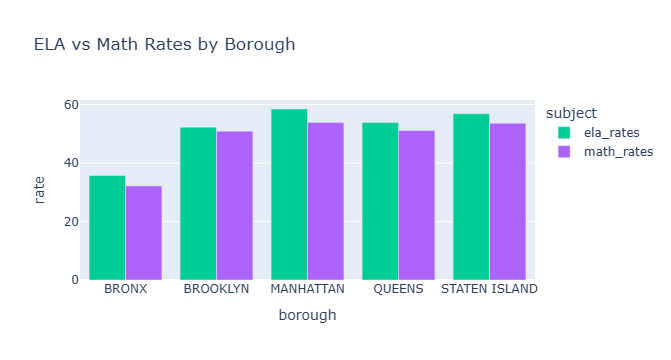

In [20]:
#Graphing ELA and Math rates based on borough
results_fig = px.bar(
    long_df,
    x = "borough",
    y = "rate",
    color = "subject",
    barmode="group",
    title = "ELA vs Math Rates by Borough",
    color_discrete_map={"ELA": "#1f77b4", "Math": "#ff7f0e"}
)
results_fig.show()
results_fig.write_html("ela_math_boroughs.html")

In [21]:
#Aggregating Math & ELA rates based on year and borough
ela_year = raw_ela_results.groupby(["year", "borough"])["ela_rates"].mean().reset_index()
math_year = raw_math_results.groupby(["year", "borough"])["math_rates"].mean().reset_index()
ela_year

,year,borough,ela_rates
0,2018,BRONX,32.357143
1,2018,BROOKLYN,47.728571
2,2018,MANHATTAN,55.214286
3,2018,QUEENS,52.200000
4,2018,STATEN ISLAND,53.685714
5,2019,BRONX,33.385714
6,2019,BROOKLYN,48.828571
7,2019,MANHATTAN,56.485714
8,2019,QUEENS,52.171429
9,2019,STATEN ISLAND,53.371429


In [22]:
#Merging ELA and Math rates by year
combined_year = ela_year.merge(math_year, on=["year", "borough"])
combined_year

,year,borough,ela_rates,math_rates
0,2018,BRONX,32.357143,26.428571
1,2018,BROOKLYN,47.728571,44.842857
2,2018,MANHATTAN,55.214286,49.700000
3,2018,QUEENS,52.200000,48.342857
4,2018,STATEN ISLAND,53.685714,46.828571
5,2019,BRONX,33.385714,30.000000
6,2019,BROOKLYN,48.828571,47.928571
7,2019,MANHATTAN,56.485714,52.900000
8,2019,QUEENS,52.171429,50.600000
9,2019,STATEN ISLAND,53.371429,49.700000


In [23]:
#Changing merged data to long data either ela or math rates
long_year = combined_year.melt(
    id_vars=["year", "borough"],
    value_vars=["ela_rates", "math_rates"],
    var_name="subject",
    value_name="rate"
)
long_year

,year,borough,subject,rate
0,2018,BRONX,ela_rates,32.357143
1,2018,BROOKLYN,ela_rates,47.728571
2,2018,MANHATTAN,ela_rates,55.214286
3,2018,QUEENS,ela_rates,52.200000
4,2018,STATEN ISLAND,ela_rates,53.685714
5,2019,BRONX,ela_rates,33.385714
6,2019,BROOKLYN,ela_rates,48.828571
7,2019,MANHATTAN,ela_rates,56.485714
8,2019,QUEENS,ela_rates,52.171429
9,2019,STATEN ISLAND,ela_rates,53.371429


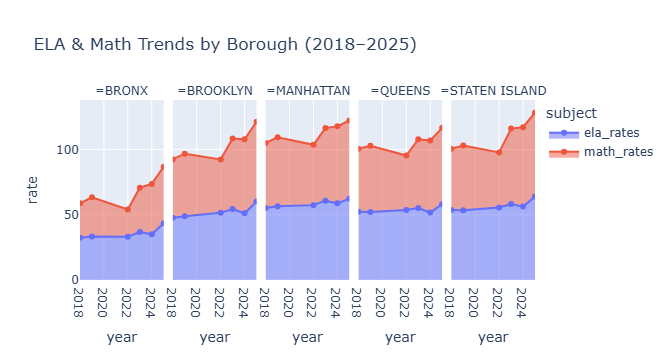

In [24]:
#Graphing merged ELA and Math rates based on borough and year
rate_year_fig = px.area(
    long_year,
    x="year",
    y="rate",
    color="subject",
    facet_col="borough",
    labels={"borough": ""},
    title="ELA & Math Trends by Borough (2018–2025)",
    markers=True
)

rate_year_fig.show()
rate_year_fig.write_html("ela_math_year.html")

## Discovery:
Now that we know there is a dynamic change in ELA, and Math rates over the years in each borough, we realised that the existence of libraries and computer centers and their numbers, won't actually directly affect these changes in results. Beacuse once a library/computer center is built, it stays there, so technically, in order to see if that affects the English literacy rates, we have to look into the *Programs* that are provided by these facilities, and not only the *no. of programs*, but the people who **actually** attended these programs. then, we would have to compare the before and after results for people who atteneded and people who did not attend, which in our case, impossible 'i.e. such data doesn't exist/no access'.
#### Access != Usage, Usage != Impact

## New Question: Are literacy‑related resources (libraries, computer centers, literacy programs) distributed equally across NYC boroughs? 'Resource Distribution'

In [25]:
raw_Computer_Centers["borough"].unique()

<StringArray>
[                                    'Manhattan',
                                      'Brooklyn',
                                        'Queens',
                                         'Bronx',
                                 'Staten Island',
 'Manhattan,Brooklyn,Bronx,Queens,Staten Island',
 'Brooklyn,Manhattan,Queens,Staten Island,Bronx',
                                      'Citywide']
Length: 8, dtype: str

In [26]:
#Filtered out 958 from 965 have exact borough locations
valid_boroughs = ["Manhattan", "Queens", "Bronx", "Brooklyn", "Staten Island"]
centers_boroughs = raw_Computer_Centers[raw_Computer_Centers["borough"].isin(valid_boroughs)]
centers_boroughs

,calendar_year,object_identification_number,oversight_agency,operator_name,status,location_name,state,borough,postcode,address_street,...,access_requirements,access_notes,url,community_district,council_district,bin,bbl,census_tract_(2020),neighborhood_tabulation_area_(nta)_(2020),location
0,2025,DFTAPCCARC297,NYC Aging,Arc Xvi Fort Washington Inc,NaN,AP Randolph Senior Center,NY,Manhattan,10039.0,"108 West 146th Street, 10039, Manhattan, New Y...",...,N,NaN,http://www.arcseniors.org,110.0,9.0,1060189.0,1.020140e+09,232.0,MN1002,POINT (-73.9364039 40.8212896)
1,2025,DFTAPCCJEW544,NYC Aging,Jewish Association For Services For The Aged,NaN,Club 76 Older Adult Center,NY,Manhattan,10023.0,"120 West 76th Street, 10023, Manhattan, New Yo...",...,Y,Age 60+,http://jasa.org,107.0,6.0,1030146.0,1.011470e+09,161.0,MN0702,POINT (-73.97818199999999 40.7803034)
2,2025,DFTAPCCBAY803,NYC Aging,Bay Ridge Center Inc. D/B/A Bay Ridge Center,NaN,Bay Ridge Center,NY,Brooklyn,11220.0,"15 Bay Ridge Avenue, 11220, Brooklyn, New York...",...,Y,Age 60+,http://Www.bayridgecenter.org,310.0,47.0,3144947.0,3.058590e+09,34.0,BK1001,POINT (-74.0350614 40.6387629)
3,2025,DYCDW119205,Department of Youth and Community Development ...,Department of Youth and Community Development ...,NaN,Dream Center Harlem,NY,Manhattan,10026.0,"205 West 119th Street, 10026, Manhattan, New Y...",...,N,NaN,http://www.dreamcenterharlem.org,110.0,9.0,1088701.0,1.019250e+09,220.0,MN1001,POINT (-73.951702 40.805646)
4,2025,DFTAPCCBOW279,NYC Aging,Bowery Residence Committee,NaN,BRC Older Adults Center,NY,Manhattan,10002.0,"30 Delancey Street, 10002, Manhattan, New York...",...,Y,Age 60+,http://www.brc.org,103.0,1.0,1079081.0,1.004200e+09,18.0,MN0302,POINT (-73.9922313 40.7203881)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
960,2026,DYCDPCCST102,Department of Youth and Community Development ...,Stanley M. Isaacs Neighborhood Center,Currently open,Stanley M. Isaacs Neighborhood Community Center,NY,Manhattan,10128.0,"415 E 93rd St, Manhattan, 10128, NY",...,NaN,NaN,http://isaacscenter.org,108.0,8.0,1082367.0,1.015730e+09,152.0,MN0803,POINT (-73.9451475 40.7812375)
961,2026,PARKS012,NYC Parks & Recreation,NYC Parks & Recreation,Temporarily closed,Hamilton Fish Recreation Center,NY,Manhattan,10002.0,"128 Pitt Street, Manhattan, 10002, NY",...,NaN,NaN,https://www.nycgovparks.org/facilities/recreat...,103.0,2.0,1081934.0,1.003400e+09,2201.0,MN0302,POINT (-73.9814613 40.7199938)
962,2026,QPL029,Queens Public Library (QPL),Queens Public Library (QPL),Currently open,Hunters Point Library,NY,Queens,11109.0,"47-40 Center Boulevard, Queens, 11109, NY",...,N,NaN,https://www.queenslibrary.org/about-us/locatio...,402.0,26.0,4594151.0,4.000190e+09,102.0,QN0201,POINT (-73.9580495 40.7453068)
963,2026,QPL045,Queens Public Library (QPL),Queens Public Library (QPL),Currently open,Pomonok Library,NY,Queens,11365.0,"158-21 Jewel Avenue, Queens, 11365, NY",...,N,NaN,https://www.queenslibrary.org/about-us/locatio...,408.0,24.0,4438294.0,4.067900e+09,122703.0,QN0802,POINT (-73.8101067 40.7326235)


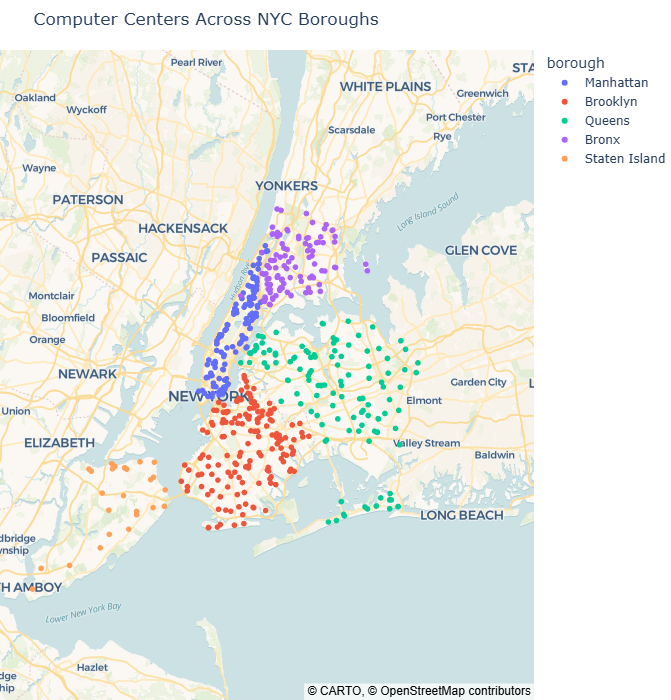

In [27]:
computer_centers_fig = px.scatter_map(
    centers_boroughs,
    lat="latitude",
    lon="longitude",
    color="borough",
    hover_name="location_name",
    zoom=9,
    height=700,
    title="Computer Centers Across NYC Boroughs"
)

computer_centers_fig.update_layout(
    mapbox_style="carto-positron",
    margin={"r":0,"t":50,"l":0,"b":0}
)

computer_centers_fig.show()
computer_centers_fig.write_html("computer_centers.html")

## Merging library tables together for all the boroughs


In [28]:
nyc_libs = pd.read_csv("Libraries_by_Borough.csv")
nyc_libs.columns

Index(['the_geom', 'NAME', 'STREETNAME', 'HOUSENUM', 'CITY', 'ZIP', 'URL',
       'BIN', 'BBL', 'X', 'Y', 'SYSTEM', 'BOROCODE'],
      dtype='str')

In [29]:
nyc_libs.columns = nyc_libs.columns.str.lower()
nyc_libs.columns

Index(['the_geom', 'name', 'streetname', 'housenum', 'city', 'zip', 'url',
       'bin', 'bbl', 'x', 'y', 'system', 'borocode'],
      dtype='str')

In [30]:
nyc_libs["city"].value_counts()

city
Brooklyn            59
New York            44
Bronx               35
Staten Island       13
Flushing             9
Long Island City     6
Jamaica              4
Bayside              3
Corona               3
Little Neck          2
Far Rockaway         2
Forest Hills         2
Richmond Hill        2
LIC                  2
Arverne              1
Bellerose            1
Briarwood            1
Broad Channel        1
Cambria Heights      1
East Elmhurst        1
Elmhurst             1
Fresh Meadows        1
Glen Oaks            1
Glendale             1
Hollis               1
Howard Beach         1
Jackson Heights      1
Laurelton            1
Maspeth              1
Middle Village       1
Ozone Park           1
Rockaway Beach       1
College Point        1
Queens Village       1
Rego Park            1
Ridgewood            1
Rosedale             1
Rockaway Park        1
South Hollis         1
South Ozone Park     1
St. Albans           1
Whitestone           1
Woodhaven            1
Woodsi

In [31]:
#Function for making the city names borough names instead...
def city_to_borough(city):
    city = city.strip().upper()
    if(city == "BROOKLYN"):
        return "BROOKLYN"
    if(city == "NEW YORK"):
        return "MANHATTAN"
    if(city == "STATEN ISLAND"):
        return "STATEN ISLAND"
    if(city == "BRONX"):
        return "BRONX"
    return "QUEENS"

nyc_libs["borough"] = nyc_libs["city"].apply(city_to_borough)
nyc_libs

,the_geom,name,streetname,housenum,city,zip,url,bin,bbl,x,y,system,borocode,borough
0,POINT (-73.95353074430393 40.80297988196676),115th Street,West 115th Street,203,New York,10026,http://www.nypl.org/locations/115th-street,"1,055,236",1018310026,"997,115.12977","231,827.652864",NYPL,1,MANHATTAN
1,POINT (-73.9348475633247 40.80301816141575),125th Street,East 125th Street,224,New York,10035,http://www.nypl.org/locations/125th-street,"1,054,674",1017890037,"1,002,287.604","231,844.894956",NYPL,1,MANHATTAN
2,POINT (-73.97736329270697 40.76080689474172),53rd Street,West 53rd Street,18,New York,10019,http://www.nypl.org/locations/53rd-street,"1,089,376",1012687503,"990,521","216,460",NYPL,1,MANHATTAN
3,POINT (-73.9693817046576 40.7621860177235),58th Street,East 58th Street,127,New York,10022,http://www.nypl.org/locations/58th-street,"1,037,165",1013130005,"992,731.946935","216,963.13174",NYPL,1,MANHATTAN
4,POINT (-73.95954994584243 40.764915006253425),67th Street,East 67th Street,328,New York,10065,http://www.nypl.org/locations/67th-street,"1,044,749",1014410038,"995,455.102906","217,958.496876",NYPL,1,MANHATTAN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211,POINT (-73.9216680312544 40.7408466968306),Sunnyside,Greenpoint Avenue,43-06,Long Island City,11104,http://www.queenslibrary.org/branch/Sunnyside?...,"4,002,111",4001730016,"1,005,956.64264","209,196.751038",QPL,4,QUEENS
212,POINT (-73.81070183926587 40.78854019464647),Whitestone,14 Road,151-10,Whitestone,11357,http://www.queenslibrary.org/branch/Whitestone...,"4,107,201",4047170025,"1,036,669","226,620",QPL,4,QUEENS
213,POINT (-73.7556194209342 40.73450483347836),Windsor Park,Bell Boulevard,79-50,Bayside,11364,http://www.queenslibrary.org/branch/Windsor-Pa...,"4,164,306",4077720001,"1,051,976.89001","206,970.9776",QPL,4,QUEENS
214,POINT (-73.86145741517984 40.69453115325741),Woodhaven,Forest Parkway,85-41,Woodhaven,11421,http://www.queenslibrary.org/branch/Woodhaven?...,"4,181,578",4088560085,"1,022,668.33783","192,343.257019",QPL,4,QUEENS


In [32]:
nyc_libs.dtypes

the_geom        str
name            str
streetname      str
housenum        str
city            str
zip           int64
url             str
bin             str
bbl           int64
x               str
y               str
system          str
borocode      int64
borough         str
dtype: object

In [33]:
nyc_libs["the_geom"].sample()

1    POINT (-73.9348475633247 40.80301816141575)
Name: the_geom, dtype: str

In [34]:
# Function for separating the long and lat values from the string the_geom column
def get_coordinates(geo_Location):
    clean_coords = geo_Location.replace("POINT (", "").replace(")", "")
    lon, lat = clean_coords.split()
    return float(lon), float(lat)

nyc_libs["longitude"], nyc_libs["latitude"] = zip(*nyc_libs["the_geom"].apply(get_coordinates))

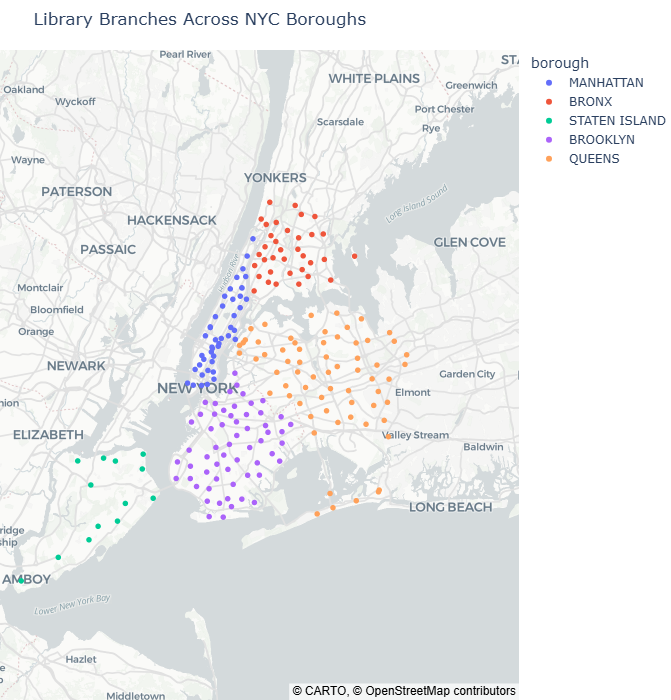

In [35]:
lib_fig = px.scatter_map(
    nyc_libs,
    lat = "latitude",
    lon = "longitude",
    color = "borough",
    hover_name = "name",
    zoom = 9,
    height = 700,
    title = "Library Branches Across NYC Boroughs"
)

lib_fig.update_layout(
    map_style = "carto-positron",
    margin={"r":0,"t":50,"l":0,"b":0}
)

lib_fig.show()
lib_fig.write_html("libraries.html")

/tmp/ipykernel_5040/2902552479.py:6: DeprecationWarning: *scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig.add_trace(go.Scattermapbox(
/tmp/ipykernel_5040/2902552479.py:15: DeprecationWarning: *scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig.add_trace(go.Scattermapbox(


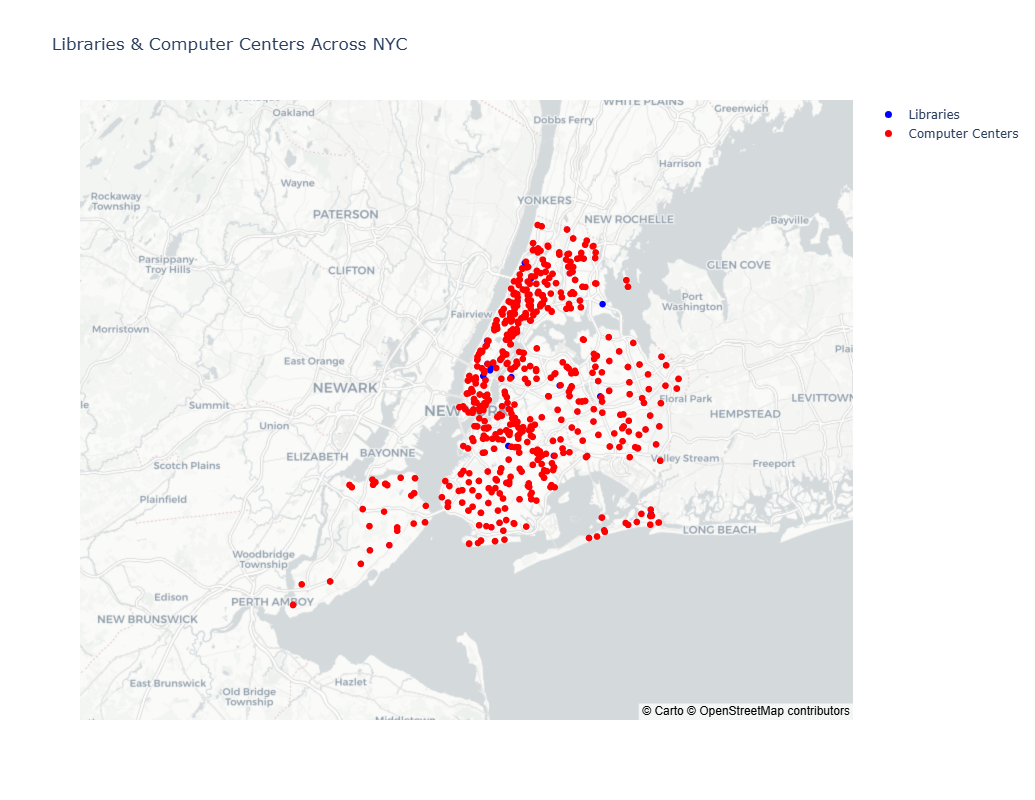

In [43]:
import plotly.graph_objects as go

fig = go.Figure()

# Libraries
fig.add_trace(go.Scattermapbox(
    lat=nyc_libs["latitude"],
    lon=nyc_libs["longitude"],
    mode="markers",
    marker=dict(size=7, color="blue"),
    name="Libraries"
))

# Computer Centers
fig.add_trace(go.Scattermapbox(
    lat=centers_boroughs["latitude"],
    lon=centers_boroughs["longitude"],
    mode="markers",
    marker=dict(size=7, color="red"),
    name="Computer Centers"
))

fig.update_layout(
    mapbox_style="carto-positron",
    mapbox_zoom=9,
    mapbox_center={"lat":40.7128, "lon":-74.0060},
    height=800,
    title="Libraries & Computer Centers Across NYC"
)

fig.show()
fig.write_html("Libraries_and_Computers.html")